# 2 · Las mediciones

Todo lo que el simulador sortea sale de acá. Cada sección responde una
pregunta, muestra el cálculo y dice qué tan lejos llega el dato — que en varios
casos es menos de lo que parece.

La base es la del cuaderno 1: vueltas representativas, en verde, sin carreras
con lluvia. Las excepciones se señalan donde ocurren.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from boxbox_ml import cache, features, neutralisation, track_status

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 3.4), "figure.dpi": 110, "font.size": 9})

CIRCUITO = "Zandvoort"
CORTES = [0.05, 0.15, 0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 0.95]

raw = pd.read_parquet(cache.cache_dir().parent / "laps_overtaking.parquet")
raw["circuit"] = raw["circuit"].map(lambda c: neutralisation.CIRCUIT_ALIASES.get(c, c))
base = features.add_labels(
    features.add_degradation(
        features.add_fuel_correction(features.mark_representative(track_status.add_flags(raw)))
    )
)

lluvia = base.groupby(["year", "round"])["Rainfall"].mean()
MOJADAS = set(lluvia[lluvia > 0.2].index)
seco = base[~pd.MultiIndex.from_frame(base[["year", "round"]]).isin(MOJADAS)]
verde = seco[seco["is_representative"] & ~seco["is_neutralised"] & ~seco["red"]]

print(f"carreras totales: {base.groupby(['year', 'round']).ngroups}")
print(f"carreras secas:   {seco.groupby(['year', 'round']).ngroups}")
print(f"vueltas verdes representativas en seco: {len(verde):,}")

carreras totales: 103
carreras secas:   95
vueltas verdes representativas en seco: 91,609


## 2.1 ¿Cuánto cuesta parar, de verdad?

Esta es la cifra central del proyecto y la que más veces salió mal.

Una parada son **dos vueltas**: la de entrada y la de salida. El costo es
cuánto tardaron esas dos por encima de lo que habrían tardado en carrera. La
pregunta es contra qué se comparan.

### El error: comparar contra la mediana de la carrera

El primer intento usó la vuelta verde mediana de **toda la carrera** como
referencia. Bajo neutralización eso le cobra al que para una lentitud que tenía
todo el mundo.

In [2]:
mediana_carrera = (
    base[base["is_representative"] & ~base["is_neutralised"]]
    .groupby(["year", "round"])["LapTime"]
    .median()
)
mal = base.join(mediana_carrera.rename("ref"), on=["year", "round"]).copy()
mal["exceso"] = mal["LapTime"] - mal["ref"]


def emparejar(frame: pd.DataFrame, columna: str) -> pd.DataFrame:
    """Une la vuelta de entrada con la de salida que le sigue, por número de vuelta."""
    entradas = frame[frame["pit_in"].astype(bool) & (frame["LapNumber"] > 1)][
        ["year", "round", "circuit", "Driver", "LapNumber", columna, "sc", "vsc", "vsc_ending", "red"]
    ].rename(columns={columna: "entrada"})
    salidas = frame[frame["pit_out"].astype(bool)][
        ["year", "round", "Driver", "LapNumber", columna]
    ].rename(columns={columna: "salida"})
    salidas = salidas.assign(LapNumber=salidas["LapNumber"] - 1)
    par = entradas.merge(salidas, on=["year", "round", "Driver", "LapNumber"], how="inner")
    par["costo"] = par["entrada"] + par["salida"]
    par["estado"] = np.select(
        [par["red"], par["sc"], par["vsc"] | par["vsc_ending"]],
        ["ROJA", "SC", "VSC"],
        default="VERDE",
    )
    return par[par["costo"].between(-10, 120)]


con_error = emparejar(mal, "exceso")
print("REFERENCIA EQUIVOCADA — mediana de la carrera entera:")
print(
    con_error.groupby("estado")["costo"]
    .agg(paradas="size", p25=lambda s: s.quantile(0.25), mediana="median", p75=lambda s: s.quantile(0.75))
    .round(1)
    .to_string()
)
print("\nDice que parar bajo safety car cuesta MÁS que en verde, que es lo contrario")
print("de lo que pasa. El error no es el signo: es la referencia.")

REFERENCIA EQUIVOCADA — mediana de la carrera entera:
        paradas   p25  mediana   p75
estado                              
SC          405  64.2     74.0  82.5
VERDE      2615  20.9     23.4  27.0
VSC         199  43.9     52.3  65.1

Dice que parar bajo safety car cuesta MÁS que en verde, que es lo contrario
de lo que pasa. El error no es el signo: es la referencia.


### La referencia correcta: la mediana del pelotón en esas mismas vueltas

Si bajo safety car todos van lentos, la comparación tiene que ser contra los
demás **en esa vuelta**, no contra un promedio de la carrera.

In [3]:
en_pista = base[~base["pit_in"].astype(bool) & ~base["pit_out"].astype(bool)]
mediana_vuelta = en_pista.groupby(["year", "round", "LapNumber"])["LapTime"].median()
bien = base.join(mediana_vuelta.rename("ref"), on=["year", "round", "LapNumber"]).copy()
bien["exceso"] = bien["LapTime"] - bien["ref"]

parada = emparejar(bien, "exceso")
tabla = (
    parada.groupby("estado")["costo"]
    .agg(
        paradas="size",
        p25=lambda s: s.quantile(0.25),
        mediana="median",
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.9),
    )
    .round(1)
)
print("REFERENCIA CORRECTA — mediana del pelotón en la misma vuelta:")
print(tabla.to_string())

REFERENCIA CORRECTA — mediana del pelotón en la misma vuelta:
        paradas   p25  mediana   p75   p90
estado                                    
SC          266   7.6     19.6  32.4  47.5
VERDE      2614  20.2     22.6  25.5  30.1
VSC         199  14.8     18.8  27.1  36.2


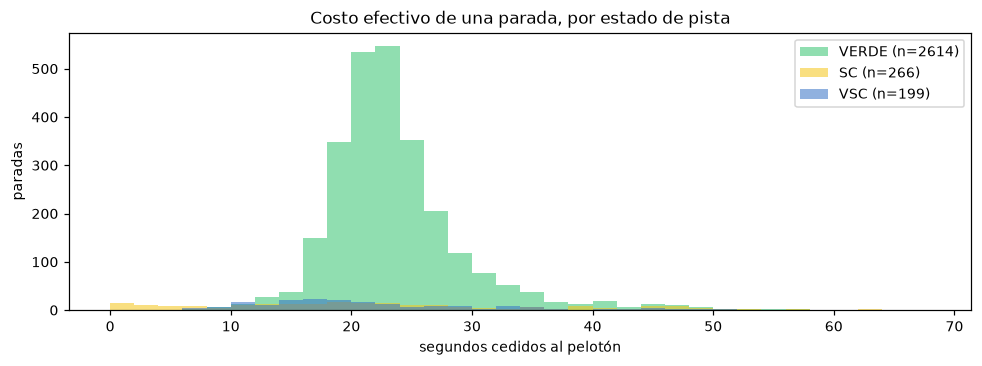

In [4]:
fig, ax = plt.subplots()
for estado, color in (("VERDE", "#35c46f"), ("SC", "#f5c518"), ("VSC", "#3671c6")):
    muestra = parada[parada["estado"] == estado]["costo"]
    ax.hist(muestra, bins=np.arange(0, 70, 2), alpha=0.55, label=f"{estado} (n={len(muestra)})", color=color)
ax.set_xlabel("segundos cedidos al pelotón")
ax.set_ylabel("paradas")
ax.set_title("Costo efectivo de una parada, por estado de pista")
ax.legend()
plt.tight_layout()
plt.show()

### Lo que la mediana esconde

En segundos el descuento del safety car es chico. Lo grande es la **forma**:

In [5]:
verde_med = parada[parada["estado"] == "VERDE"]["costo"].median()
for estado in ("VERDE", "SC", "VSC"):
    m = parada[parada["estado"] == estado]["costo"]
    print(
        f"{estado:6s} n={len(m):5d}  p25 {m.quantile(0.25):5.1f}  mediana {m.median():5.1f}"
        f"  p75 {m.quantile(0.75):5.1f}   ({m.median() / verde_med:.2f}x verde)"
    )
print("\nEl primer cuartil bajo safety car es un tercio del costo en verde: ésa es")
print("la parada barata de la que hablan los comentaristas. El tercer cuartil es")
print("peor que verde. Reaccionar rápido y reaccionar tarde no son la misma")
print("decisión, y esta medición no las distingue porque no registra a qué altura")
print("del período cayó la parada. Es la próxima medición que falta.")

VERDE  n= 2614  p25  20.2  mediana  22.6  p75  25.5   (1.00x verde)
SC     n=  266  p25   7.6  mediana  19.6  p75  32.4   (0.87x verde)
VSC    n=  199  p25  14.8  mediana  18.8  p75  27.1   (0.83x verde)

El primer cuartil bajo safety car es un tercio del costo en verde: ésa es
la parada barata de la que hablan los comentaristas. El tercer cuartil es
peor que verde. Reaccionar rápido y reaccionar tarde no son la misma
decisión, y esta medición no las distingue porque no registra a qué altura
del período cayó la parada. Es la próxima medición que falta.


## 2.2 ¿Cuándo sale el safety car y cuánto dura?

El optimizador sortea carreras enteras, así que necesita la tasa, el momento y
la duración. Se reconstruyen los períodos como tramos contiguos de vueltas con
la bandera activa.

In [6]:
por_vuelta = (
    base.groupby(["year", "round", "circuit", "LapNumber", "total_laps"])[["sc", "vsc", "red"]]
    .any()
    .reset_index()
)
por_vuelta["share"] = por_vuelta["LapNumber"] / por_vuelta["total_laps"]

periodos = []
for (anio, ronda), carrera in por_vuelta.groupby(["year", "round"]):
    carrera = carrera.sort_values("LapNumber")
    for clase in ("sc", "vsc"):
        activo = carrera[clase].to_numpy()
        vueltas = carrera["LapNumber"].to_numpy()
        shares = carrera["share"].to_numpy()
        inicio = None
        for i, on in enumerate(np.append(activo, False)):
            if on and inicio is None:
                inicio = i
            elif not on and inicio is not None:
                periodos.append(
                    {
                        "year": anio,
                        "round": ronda,
                        "circuit": carrera["circuit"].iloc[0],
                        "clase": clase,
                        "inicio": float(shares[inicio]),
                        "vueltas": int(vueltas[i - 1] - vueltas[inicio] + 1),
                    }
                )
                inicio = None

periodos = pd.DataFrame(periodos)
carreras = por_vuelta[["year", "round"]].drop_duplicates()
cuenta = (
    periodos.groupby(["year", "round", "clase"])
    .size()
    .unstack(fill_value=0)
    .reindex(pd.MultiIndex.from_frame(carreras), fill_value=0)
)

for clase in ("sc", "vsc"):
    print(
        f"{clase.upper():4s} P(al menos uno) = {(cuenta[clase] > 0).mean():.3f}"
        f"   períodos por carrera = {cuenta[clase].mean():.2f}"
    )
print(f"\nsobre {len(carreras)} carreras (incluidas las mojadas: un safety car es un")
print("safety car llueva o no)")

SC   P(al menos uno) = 0.544   períodos por carrera = 0.70
VSC  P(al menos uno) = 0.476   períodos por carrera = 0.68

sobre 103 carreras (incluidas las mojadas: un safety car es un
safety car llueva o no)


In [7]:
print("duración, en vueltas:")
print(
    periodos.groupby("clase")["vueltas"]
    .agg(n="count", p25=lambda s: s.quantile(0.25), mediana="median", p75=lambda s: s.quantile(0.75), media="mean")
    .round(2)
    .to_string()
)
print("\nmomento de inicio, como fracción de la carrera:")
for clase in ("sc", "vsc"):
    q = periodos[periodos["clase"] == clase]["inicio"].quantile(CORTES)
    print(f"  {clase.upper()}: " + ", ".join(f"{v:.3f}" for v in q))

duración, en vueltas:
        n  p25  mediana  p75  media
clase                              
sc     72  4.0      4.0  7.0   5.11
vsc    70  2.0      3.0  4.0   3.31

momento de inicio, como fracción de la carrera:
  SC: 0.014, 0.018, 0.033, 0.120, 0.306, 0.457, 0.619, 0.744, 0.877
  VSC: 0.027, 0.102, 0.218, 0.314, 0.414, 0.667, 0.715, 0.792, 0.937


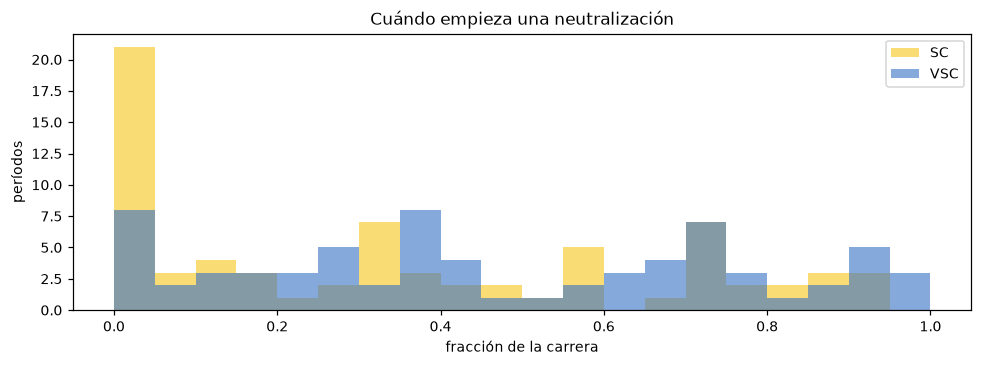

El safety car se concentra en el arranque: la primera vuelta es donde
choca la gente. Eso importa para la estrategia, porque una neutralización
temprana llega antes de que nadie tenga la ventana abierta.


In [8]:
fig, ax = plt.subplots()
for clase, color in (("sc", "#f5c518"), ("vsc", "#3671c6")):
    ax.hist(
        periodos[periodos["clase"] == clase]["inicio"],
        bins=np.arange(0, 1.05, 0.05),
        alpha=0.6,
        label=clase.upper(),
        color=color,
    )
ax.set_xlabel("fracción de la carrera")
ax.set_ylabel("períodos")
ax.set_title("Cuándo empieza una neutralización")
ax.legend()
plt.tight_layout()
plt.show()
print("El safety car se concentra en el arranque: la primera vuelta es donde")
print("choca la gente. Eso importa para la estrategia, porque una neutralización")
print("temprana llega antes de que nadie tenga la ventana abierta.")

## 2.3 ¿Cuánto varía el ritmo de una vuelta a otra?

Dentro de una tanda se ajusta una recta de tiempo corregido contra vuelta de
tanda. La pendiente es el desgaste; el **desvío de los residuos** es todo lo
demás: tráfico, viento, una entrada ancha.

In [9]:
MIN_TANDA = 8
filas = []
for claves, tanda in verde.groupby(features.STINT_KEYS, dropna=False):
    ritmo = tanda["lap_time_fuel_corrected"].to_numpy(dtype=float)
    posicion = tanda["stint_lap"].to_numpy(dtype=float)
    if len(ritmo) < MIN_TANDA or not np.isfinite(ritmo).all():
        continue
    pendiente, intercepto = np.polyfit(posicion, ritmo, 1)
    residuo = ritmo - (pendiente * posicion + intercepto)
    filas.append(
        {
            "year": claves[0],
            "round": claves[1],
            "driver": claves[2],
            "circuit": tanda["circuit"].iloc[0],
            "compound": tanda["Compound"].iloc[0],
            "vueltas": len(ritmo),
            "pendiente": pendiente,
            "residuo_sd": float(residuo.std(ddof=2)),
        }
    )

tandas = pd.DataFrame(filas)
lo, hi = tandas["residuo_sd"].quantile([0.005, 0.995])
recortadas = tandas[tandas["residuo_sd"].between(lo, hi)]
print(f"tandas ajustadas: {len(tandas):,} (>= {MIN_TANDA} vueltas), {len(recortadas):,} tras recortar el 1% extremo")
print()
print(recortadas["residuo_sd"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_string())

tandas ajustadas: 4,209 (>= 8 vueltas), 4,165 tras recortar el 1% extremo

count    4165.000
mean        0.621
std         0.749
min         0.124
10%         0.230
25%         0.320
50%         0.457
75%         0.669
90%         1.032
max         9.196


In [10]:
print("por compuesto:")
print(
    recortadas.groupby("compound")
    .agg(tandas=("vueltas", "count"), mediana_sd=("residuo_sd", "median"))
    .sort_values("mediana_sd")
    .round(3)
    .to_string()
)
print("\npor temporada — ¿alcanza una sola constante?")
print(
    recortadas.groupby("year")
    .agg(tandas=("vueltas", "count"), mediana_sd=("residuo_sd", "median"))
    .round(3)
    .to_string()
)
print("\nLas tres secas quedan a menos de 0,05 s entre sí y las cinco temporadas")
print("entre 0,440 y 0,487. El simulador usa un solo número: 0,457 s.")

por compuesto:
              tandas  mediana_sd
compound                        
nan               15       0.316
MEDIUM          1709       0.428
SOFT             625       0.473
HARD            1727       0.475
None              17       0.538
WET                2       1.282
INTERMEDIATE      70       1.314

por temporada — ¿alcanza una sola constante?
      tandas  mediana_sd
year                    
2022     863       0.470
2023     887       0.442
2024     894       0.434
2025     953       0.452
2026     568       0.521

Las tres secas quedan a menos de 0,05 s entre sí y las cinco temporadas
entre 0,440 y 0,487. El simulador usa un solo número: 0,457 s.


## 2.4 ¿Cómo se distribuye el desgaste? (y por qué no es normal)

El simulador sorteaba el ritmo de caída de una normal con el desvío medido.
La distribución real no tiene esa forma ni de casualidad.

In [11]:
secas = recortadas[recortadas["compound"].isin(["SOFT", "MEDIUM", "HARD"])]
aqui = secas[secas["circuit"] == CIRCUITO]
forma = aqui.groupby("compound")["pendiente"].agg(
    n="count", mediana="median", sd="std", asimetria="skew", curtosis=lambda s: s.kurtosis()
)
print(f"{CIRCUITO}, forma de la distribución del ritmo de caída:")
print(forma.round(3).to_string())
print("\nUna normal tiene curtosis 0. Estos valores dicen que unas pocas tandas")
print("catastróficas estiran la cola y hacen que el desvío mienta.")

Zandvoort, forma de la distribución del ritmo de caída:
           n  mediana     sd  asimetria  curtosis
compound                                         
HARD      79    0.056  0.041     -1.301     5.878
MEDIUM    68    0.060  0.082      3.725    25.567
SOFT      67    0.067  0.091     -1.973     5.153

Una normal tiene curtosis 0. Estos valores dicen que unas pocas tandas
catastróficas estiran la cola y hacen que el desvío mienta.


In [12]:
cuantiles = aqui.groupby("compound")["pendiente"].apply(lambda s: s.quantile(CORTES)).unstack()
print(f"{CIRCUITO}, cortes de la distribución (s/vuelta):")
print(cuantiles.round(4).to_string())
print("\nEl blando tiene desvío 0,66 s/vuelta pero entre el percentil 5 y el 95 va")
print("de −0,18 a 0,14. Sortear de una normal con ese desvío daba tandas")
print("imposibles varias veces por carrera. El simulador invierte estos cortes.")

Zandvoort, cortes de la distribución (s/vuelta):
            0.05    0.15    0.25    0.35    0.50    0.65    0.75    0.85    0.95
compound                                                                        
HARD     -0.0113  0.0252  0.0332  0.0420  0.0562  0.0664  0.0722  0.0874  0.1222
MEDIUM   -0.0324  0.0324  0.0426  0.0523  0.0603  0.0726  0.0855  0.0982  0.1241
SOFT     -0.1352 -0.0001  0.0230  0.0525  0.0673  0.0872  0.1025  0.1156  0.1414

El blando tiene desvío 0,66 s/vuelta pero entre el percentil 5 y el 95 va
de −0,18 a 0,14. Sortear de una normal con ese desvío daba tandas
imposibles varias veces por carrera. El simulador invierte estos cortes.


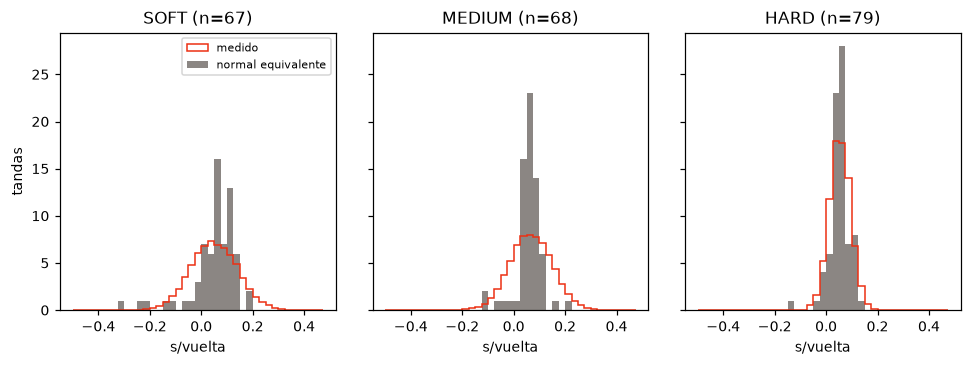

In [13]:
fig, axes = plt.subplots(1, 3, sharey=True)
for ax, compuesto in zip(axes, ("SOFT", "MEDIUM", "HARD"), strict=True):
    muestra = aqui[aqui["compound"] == compuesto]["pendiente"]
    ax.hist(muestra, bins=np.arange(-0.5, 0.5, 0.025), color="#8b8683")
    normal = np.random.default_rng(0).normal(muestra.mean(), muestra.std(), 20000)
    ax.hist(normal, bins=np.arange(-0.5, 0.5, 0.025), histtype="step", color="#ec3013", weights=np.full(20000, len(muestra) / 20000))
    ax.set_title(f"{compuesto} (n={len(muestra)})")
    ax.set_xlabel("s/vuelta")
axes[0].set_ylabel("tandas")
axes[0].legend(["medido", "normal equivalente"], fontsize=7)
plt.tight_layout()
plt.show()

## 2.5 ¿El desgaste crece en línea recta? (no, y el motivo importa)

El optimizador extrapola una pendiente ajustada sobre toda una tanda. Eso vale
sólo si el déficit crece derecho.

In [14]:
curva = base[
    base["is_representative"]
    & ~base["is_neutralised"]
    & ~base["red"]
    & base["degradation_s"].between(-3, 8)
    & base["Compound"].isin(["SOFT", "MEDIUM", "HARD"])
]
tramos = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30), (31, 35), (36, 45), (46, 70)]
filas = []
for bajo, alto in tramos:
    ventana = curva[curva["stint_lap"].between(bajo, alto)]
    fila = {"vueltas": f"{bajo}-{alto}", "n": len(ventana)}
    for compuesto in ("SOFT", "MEDIUM", "HARD"):
        muestra = ventana[ventana["Compound"] == compuesto]["degradation_s"]
        fila[compuesto] = round(muestra.mean(), 3) if len(muestra) > 30 else np.nan
    filas.append(fila)
perfil = pd.DataFrame(filas)
perfil

,vueltas,n,SOFT,MEDIUM,HARD
0,1-5,16543,0.133,0.141,0.098
1,6-10,21118,0.386,0.222,0.237
2,11-15,18177,0.813,0.507,0.468
3,16-20,13776,1.022,0.745,0.686
4,21-25,9328,1.068,0.828,0.868
5,26-30,5862,0.945,0.878,0.941
6,31-35,3410,1.147,0.842,0.936
7,36-45,2851,2.169,0.858,1.156
8,46-70,812,NaN,0.730,1.030


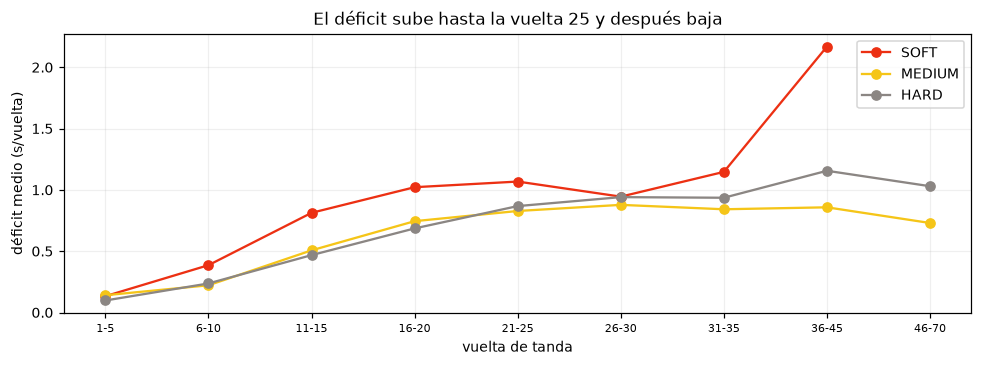

In [15]:
fig, ax = plt.subplots()
for compuesto, color in (("SOFT", "#ec3013"), ("MEDIUM", "#f5c518"), ("HARD", "#8b8683")):
    ax.plot(range(len(perfil)), perfil[compuesto], marker="o", label=compuesto, color=color)
ax.set_xticks(range(len(perfil)))
ax.set_xticklabels(perfil["vueltas"], fontsize=7)
ax.set_xlabel("vuelta de tanda")
ax.set_ylabel("déficit medio (s/vuelta)")
ax.set_title("El déficit sube hasta la vuelta 25 y después baja")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
print("ajuste cuadrático del déficit contra vuelta de tanda:")
for compuesto in ("SOFT", "MEDIUM", "HARD"):
    muestra = curva[curva["Compound"] == compuesto]
    k = muestra["stint_lap"].to_numpy(dtype=float)
    d = muestra["degradation_s"].to_numpy(dtype=float)
    cuad = np.polyfit(k, d, 2)
    print(f"  {compuesto:7s} n={len(muestra):6d}   {cuad[0]:+.5f} k²  {cuad[1]:+.4f} k   -> cóncavo")

vida = base.groupby([*features.STINT_KEYS, "Compound"], dropna=False)["stint_lap"].max()
vida = vida.reset_index(name="largo")
vida = vida[vida["Compound"].isin(["SOFT", "MEDIUM", "HARD"])]
print("\ncuánto dura un juego, en vueltas:")
print(
    vida.groupby("Compound")["largo"]
    .agg(tandas="count", mediana="median", p90=lambda s: s.quantile(0.9), mas_de_40=lambda s: (s > 40).mean())
    .round(3)
    .to_string()
)

ajuste cuadrático del déficit contra vuelta de tanda:
  SOFT    n= 11779   -0.00040 k²  +0.0634 k   -> cóncavo
  MEDIUM  n= 35207   -0.00095 k²  +0.0629 k   -> cóncavo
  HARD    n= 44943   -0.00088 k²  +0.0659 k   -> cóncavo

cuánto dura un juego, en vueltas:
          tandas  mediana   p90  mas_de_40
Compound                                  
HARD        2002     25.0  41.0      0.109
MEDIUM      2240     18.0  31.0      0.025
SOFT        1152     13.0  25.0      0.003


**Ningún neumático mejora con el uso.** La curva baja porque los juegos que
llegan a las treinta vueltas son los que aguantaron: los que no, se cambiaron.
Es sesgo de supervivencia, y el ajuste cuadrático cóncavo es el mismo artefacto
de otra forma.

Consecuencia práctica: **los datos no pueden ponerle precio a una tanda
larga**, y lo que dicen de ella es optimista. El optimizador tiene prohibido
proponer tandas más largas que el percentil 90 medido —41 vueltas en duro, 31
en medio, 25 en blando— porque más allá de eso estaría afirmando algo que la
medición no sostiene.

## 2.6 ¿Cuántas paradas, cuándo y con qué?

Las tres eran decisiones del programador y ahora se sortean de lo medido. Sólo
cuentan las paradas **estratégicas**: se descartan las gratis bajo bandera roja
y las carreras con lluvia.

In [17]:
corridas = seco.groupby(["year", "round", "Driver"]).agg(
    vueltas=("LapNumber", "max"), total=("total_laps", "max"), circuit=("circuit", "first")
)
llegaron = corridas[corridas["vueltas"] >= 0.9 * corridas["total"]]

estrategicas = seco[seco["strategic_stop"] & (seco["LapNumber"] > 1)].sort_values(
    ["year", "round", "Driver", "LapNumber"]
)
estrategicas["nth"] = estrategicas.groupby(["year", "round", "Driver"]).cumcount() + 1
estrategicas["share"] = estrategicas["LapNumber"] / estrategicas["total_laps"]

DESDE = 30 / 72
tardias = estrategicas[estrategicas["share"] > DESDE]
restantes = tardias.groupby(["year", "round", "Driver"]).size().rename("quedan")
plan = llegaron.join(restantes).fillna({"quedan": 0})
plan["quedan"] = plan["quedan"].astype(int)

print("paradas que le quedan a un auto desde la vuelta 30 de 72:")
for donde, muestra in ((CIRCUITO, plan[plan["circuit"] == CIRCUITO]), ("todos", plan)):
    dist = muestra["quedan"].value_counts(normalize=True).sort_index()
    print(f"  {donde:10s} (n={len(muestra):4d}) " + "  ".join(f"{k}:{v:.3f}" for k, v in dist.items()))

paradas que le quedan a un auto desde la vuelta 30 de 72:
  Zandvoort  (n=  73) 0:0.151  1:0.493  2:0.192  3:0.164
  todos      (n=1686) 0:0.249  1:0.586  2:0.122  3:0.026  4:0.015  5:0.002


In [18]:
print("dónde caen esas paradas tardías, como fracción de la carrera:")
for donde, muestra in ((CIRCUITO, tardias[tardias["circuit"] == CIRCUITO]), ("todos", tardias)):
    q = muestra["share"].quantile(CORTES)
    print(f"  {donde:10s} (n={len(muestra):5d}) " + ", ".join(f"{v:.3f}" for v in q))

print("\na qué compuesto se cambia, en paradas tardías:")
calzan = tardias[
    tardias["next_compound"].isin(["SOFT", "MEDIUM", "HARD"])
    & tardias["Compound"].isin(["SOFT", "MEDIUM", "HARD"])
]
matriz = calzan.groupby(["Compound", "next_compound"]).size().unstack(fill_value=0)
print((matriz.T / matriz.sum(axis=1)).T.round(3).to_string())
print("\nDe duro a duro es el 41%. Parece violar B6.3.8, pero son paradas reales de")
print("carreras que cumplieron: el auto ya había usado el otro compuesto antes.")
print("Forzar el cambio en cada parada daría carreras menos realistas, no más.")

dónde caen esas paradas tardías, como fracción de la carrera:
  Zandvoort  (n=  109) 0.458, 0.533, 0.597, 0.653, 0.722, 0.750, 0.778, 0.789, 0.817
  todos      (n= 1768) 0.442, 0.485, 0.540, 0.576, 0.634, 0.698, 0.741, 0.792, 0.943

a qué compuesto se cambia, en paradas tardías:
next_compound   HARD  MEDIUM   SOFT
Compound                           
HARD           0.409   0.379  0.212
MEDIUM         0.501   0.172  0.327
SOFT           0.104   0.264  0.632

De duro a duro es el 41%. Parece violar B6.3.8, pero son paradas reales de
carreras que cumplieron: el auto ya había usado el otro compuesto antes.
Forzar el cambio en cada parada daría carreras menos realistas, no más.


## 2.7 ¿Cuántas paradas ocurren bajo neutralización?

Es la cifra que sostiene la tesis del proyecto.

In [19]:
bajo_sc = estrategicas.groupby("circuit")["is_neutralised"].agg(paradas="size", bajo_sc="mean")
print(f"todos los circuitos: {estrategicas['is_neutralised'].mean():.3f} de las paradas estratégicas")
print(f"{CIRCUITO}: {estrategicas[estrategicas['circuit'] == CIRCUITO]['is_neutralised'].mean():.3f}")
print("\nextremos por circuito:")
print(
    pd.concat([bajo_sc.sort_values("bajo_sc").head(4), bajo_sc.sort_values("bajo_sc").tail(4)])
    .round(3)
    .to_string()
)
print("\nZandvoort para más que el promedio, y acá está el mecanismo: donde la")
print("parada sale barata, se para más.")

todos los circuitos: 0.228 de las paradas estratégicas
Zandvoort: 0.357

extremos por circuito:
              paradas  bajo_sc
circuit                       
Yas Island        129    0.008
Mexico City        99    0.030
Budapest          156    0.045
São Paulo         120    0.083
Lusail            157    0.446
Jeddah             80    0.462
Montréal          183    0.530
Le Castellet       28    0.607

Zandvoort para más que el promedio, y acá está el mecanismo: donde la
parada sale barata, se para más.


## 2.8 ¿Se puede rankear los circuitos por dificultad para adelantar?

Se cuentan los **cambios de posición en pista** por vuelta en verde: pares que
se cruzan entre dos vueltas consecutivas, descontando a cualquiera que haya
tocado boxes.

Esta sección es un ejemplo de medición que **no alcanza**, y decirlo es el
resultado.

In [20]:
def intercambios(antes: pd.DataFrame, despues: pd.DataFrame) -> tuple[int, int]:
    unido = antes.merge(despues, on="Driver", suffixes=("_a", "_b"))
    limpio = unido[
        ~unido["pit_in_a"] & ~unido["pit_out_a"] & ~unido["pit_in_b"] & ~unido["pit_out_b"]
    ]
    if len(limpio) < 2:
        return 0, 0
    a = limpio["Position_a"].to_numpy()
    b = limpio["Position_b"].to_numpy()
    cruzados = np.sign(a[:, None] - a[None, :]) != np.sign(b[:, None] - b[None, :])
    return int(np.triu(cruzados, 1).sum()), len(limpio)


filas = []
for (anio, ronda), carrera in seco.groupby(["year", "round"]):
    limpia = carrera[~carrera["is_neutralised"] & ~carrera["red"]]
    por_lap = dict(list(limpia.groupby("LapNumber")))
    total, contadas = 0, 0
    for lap in sorted(por_lap):
        if lap + 1 not in por_lap:
            continue
        cambios, pilotos = intercambios(por_lap[lap], por_lap[lap + 1])
        if pilotos < 2:
            continue
        total += cambios
        contadas += 1
    if contadas < 10:
        continue
    filas.append(
        {"year": anio, "round": ronda, "circuit": carrera["circuit"].iloc[0], "por_vuelta": total / contadas}
    )

adelantamientos = pd.DataFrame(filas)
por_circuito = (
    adelantamientos.groupby("circuit")
    .agg(carreras=("round", "count"), por_vuelta=("por_vuelta", "mean"))
    .sort_values("por_vuelta")
)
print(f"carreras medidas: {len(adelantamientos)}  circuitos: {len(por_circuito)}")
print(por_circuito.head(6).round(3).to_string())
print("...")
print(por_circuito.tail(4).round(3).to_string())

carreras medidas: 95  circuitos: 25
           carreras  por_vuelta
circuit                        
Monaco            4       0.172
Budapest          4       0.408
Lusail            3       0.453
Baku              4       0.486
Zandvoort         4       0.502
Imola             3       0.518
...
            carreras  por_vuelta
circuit                         
Yas Island         4       0.927
Shanghai           3       0.947
Monza              4       1.207
Las Vegas          3       1.451


### El test que decide si el ranking sirve

Si la dificultad es una propiedad del circuito, tiene que repetirse. Se
correlaciona la media de cada circuito en 2022-23 contra la de 2024-26.

In [21]:
temprano = adelantamientos[adelantamientos["year"] <= 2023].groupby("circuit")["por_vuelta"].mean()
tarde = adelantamientos[adelantamientos["year"] >= 2024].groupby("circuit")["por_vuelta"].mean()
ambas = pd.concat([temprano.rename("2022-23"), tarde.rename("2024-26")], axis=1).dropna()
r = ambas["2022-23"].corr(ambas["2024-26"])
fiabilidad = max(0.0, 2 * r / (1 + r))
print(f"circuitos presentes en las dos mitades: {len(ambas)}")
print(f"correlación entre mitades:              {r:.3f}")
print(f"fiabilidad de la muestra completa (Spearman-Brown): {fiabilidad:.3f}")

circuitos presentes en las dos mitades: 23
correlación entre mitades:              0.209
fiabilidad de la muestra completa (Spearman-Brown): 0.346


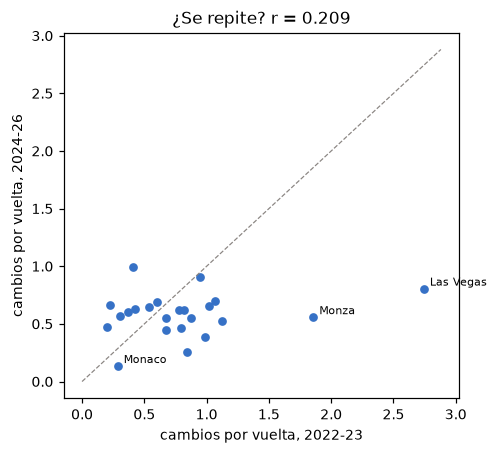

In [22]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(ambas["2022-23"], ambas["2024-26"], s=22, color="#3671c6")
for nombre, fila in ambas.iterrows():
    if nombre in ("Monaco", "Monza", "Las Vegas"):
        ax.annotate(nombre, (fila["2022-23"], fila["2024-26"]), fontsize=7, xytext=(4, 2), textcoords="offset points")
limite = float(ambas.to_numpy().max()) * 1.05
ax.plot([0, limite], [0, limite], color="#8b8683", lw=0.8, ls="--")
ax.set_xlabel("cambios por vuelta, 2022-23")
ax.set_ylabel("cambios por vuelta, 2024-26")
ax.set_title(f"¿Se repite? r = {r:.3f}")
plt.tight_layout()
plt.show()

In [23]:
media_global = adelantamientos["por_vuelta"].mean()
por_circuito["encogido"] = media_global + fiabilidad * (por_circuito["por_vuelta"] - media_global)
print(f"media global: {media_global:.3f} cambios por vuelta en verde")
print(f"rango crudo:    {por_circuito['por_vuelta'].min():.3f} a {por_circuito['por_vuelta'].max():.3f}")
print(f"rango encogido: {por_circuito['encogido'].min():.3f} a {por_circuito['encogido'].max():.3f}")
print("\nCon fiabilidad de 0,35, dos tercios de la diferencia aparente entre")
print("circuitos es ruido de una tarde. Lo que sobrevive al encogimiento son los")
print("extremos: Mónaco abajo, Las Vegas y Monza arriba. El medio de la tabla no")
print("es separable, y el medidor de la interfaz se rotula como puesto en un")
print("ranking y no como medición del circuito.")

media global: 0.683 cambios por vuelta en verde
rango crudo:    0.172 a 1.451
rango encogido: 0.506 a 0.949

Con fiabilidad de 0,35, dos tercios de la diferencia aparente entre
circuitos es ruido de una tarde. Lo que sobrevive al encogimiento son los
extremos: Mónaco abajo, Las Vegas y Monza arriba. El medio de la tabla no
es separable, y el medidor de la interfaz se rotula como puesto en un
ranking y no como medición del circuito.


## 2.9 Resumen de lo que alimenta al simulador

| Cantidad | Valor | Muestra |
|---|---|---|
| Vuelta verde en Zandvoort 2026 | 77,861 s | 1.119 vueltas |
| Ruido de una vuelta | sd 0,457 s | 4.407 tandas |
| Ritmo de caída | cortes empíricos por compuesto | 80-98 tandas |
| Pérdida de boxes en verde | 22,6 s (p25 20,2 · p75 25,5) | 2.614 paradas |
| Pérdida bajo safety car | 19,5 s (p25 7,5 · p75 31,5) | 264 paradas |
| P(safety car) | 0,54 global · 0,60 Zandvoort | 103 carreras |
| Duración del safety car | mediana 4 vueltas · 5,5 en Zandvoort | 72 períodos |
| Paradas restantes desde V30 | 0:0,15 · 1:0,49 · 2:0,19 · 3:0,16 | 73 autos |
| Tanda más larga admitida | 41 duro · 31 medio · 25 blando | p90 medido |

El uso de todo esto está en `03-busqueda-genetica.ipynb`.